In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import xarray as xr
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.linear_model import QuantileRegressor
import cartopy.crs as ccrs

Open data

In [2]:
PATH = '/climca/people/glattus/Hindcast_data_ready'

def df_xr_prep(df):
    da=df.to_xarray()
    da=da.rename({'index':'year'})
    return da

#spring
ocean_SON_xr=xr.open_dataset(PATH+'/ENSO_IOD_SON.nc').drop_vars('lead_block').rename({'nino34':'ENSO', 'iod_index':'IOD'})
SAM_SON_xr=xr.open_dataset(PATH+'/SAM_ready_SON.nc')
SPV_SON_xr=xr.open_dataset(PATH+'/SPV_SON.nc').drop_vars(['lead_block', 'pressure_level']).rename({'u':'SPV'})

#summer
#ocean_DJF_xr=xr.open_dataset(PATH+'/ENSO_IOB_DJF.nc').drop_vars('lead_block').rename({'nino34':'ENSO'})
#SAM_DJF_xr=xr.open_dataset(PATH+'/SAM_ready_DJF.nc')
#VB_DJF_xr=xr.open_dataset(PATH+'/VB_DOY_combined.nc').rename({'VB_DOY':'VB'})


In [3]:
#Temp & precip data
target_SON_xr=xr.open_dataset(PATH+'/Target_vars_SON_areas.nc')

#target_DJF_xr=xr.open_dataset(PATH+'/Target_vars_DJF_areas.nc')

display(target_SON_xr)

<xarray.Dataset> Size: 534MB
Dimensions:                  (sample: 34272, latitude: 36, longitude: 27)
Coordinates:
  * latitude                 (latitude) float64 288B -20.0 -21.0 ... -54.0 -55.0
  * longitude                (longitude) float64 216B 285.0 286.0 ... 311.0
    lead_block               <U9 36B ...
    init_month               (sample) int64 274kB ...
    season                   (sample) <U3 411kB ...
    forecast_reference_time  (sample) datetime64[ns] 274kB ...
    number                   (sample) int64 274kB ...
    lat                      (latitude) float64 288B ...
    lon                      (longitude) float64 216B ...
Dimensions without coordinates: sample
Data variables:
    t2m                      (sample, latitude, longitude) float64 266MB ...
    tp                       (sample, latitude, longitude) float64 266MB ...

In [4]:
#function for excluding ssw years
def exclude_years(ds, years_list=[2002,2019]):
    years = ds.forecast_reference_time.dt.year.compute()

    keep = ~years.isin(years_list)

    return ds.isel(sample=keep)

In [5]:
def align_hindcast_arrays(
    array_list,
    years_list,
    names=None,
    sample_coords=None,
    reference=0,
    verbose=True
):
    """
    Check and align xarray Datasets/DataArrays containing hindcast samples.

    Samples are identified by a combination of coordinates, by default:

        number
        init_month
        season
        forecast_reference_time

    The function:
      1. checks dimensions and required coordinates
      2. checks coordinate equality
      3. checks whether all datasets contain the same sample identities
      4. detects ordering differences
      5. reorders all datasets to the reference dataset's sample order
      6. verifies the final alignment

    Parameters
    ----------
    array_list : list
        List of xarray Dataset/DataArray objects.

    names : list, optional
        Names for diagnostic output.

    sample_coords : list, optional
        Coordinates defining a unique hindcast sample.

    reference : int
        Index of the dataset whose sample ordering is used
        as the reference.

    verbose : bool
        Print diagnostics.

    Returns
    -------
    aligned_arrays : list
        Aligned xarray objects.
    """

    # ---------------------------------------------------------
    # 1. Defaults
    # ---------------------------------------------------------

    if sample_coords is None:
        sample_coords = [
            "number",
            "init_month",
            "season",
            "forecast_reference_time"
        ]

    n_arrays = len(array_list)

    if names is None:
        names = [
            f"array_{i}"
            for i in range(n_arrays)
        ]

    if len(names) != n_arrays:
        raise ValueError(
            "names must have the same length as array_list"
        )

    if reference < 0 or reference >= n_arrays:
        raise ValueError(
            "reference must be a valid array index"
        )

    # ---------------------------------------------------------
    # 2. Basic checks
    # ---------------------------------------------------------

    if verbose:
        print("=" * 70)
        print("BASIC STRUCTURE")
        print("=" * 70)

    for name, arr in zip(names, array_list):

        if not isinstance(
            arr,
            (xr.Dataset, xr.DataArray)
        ):
            raise TypeError(
                f"{name} is not an xarray Dataset/DataArray"
            )

        if "sample" not in arr.dims:
            raise ValueError(
                f"{name} does not contain a 'sample' dimension"
            )

        print(
            f"{name:15s} "
            f"sample size = {arr.sizes['sample']}"
        )

    # ---------------------------------------------------------
    # 3. Check sample sizes
    # ---------------------------------------------------------

    sample_sizes = [
        arr.sizes["sample"]
        for arr in array_list
    ]

    if len(set(sample_sizes)) != 1:

        raise ValueError(
            "Datasets have different sample sizes:\n"
            + "\n".join(
                f"{name}: {size}"
                for name, size in zip(
                    names,
                    sample_sizes
                )
            )
        )

    n_samples = sample_sizes[0]

    # ---------------------------------------------------------
    # 4. Check sample coordinates
    # ---------------------------------------------------------

    if verbose:
        print("\n" + "=" * 70)
        print("CHECKING SAMPLE COORDINATES")
        print("=" * 70)

    for name, arr in zip(names, array_list):

        for coord in sample_coords:

            if coord not in arr.coords:

                raise ValueError(
                    f"{name} is missing coordinate "
                    f"{coord!r}"
                )

            if arr[coord].dims != ("sample",):

                raise ValueError(
                    f"{name}[{coord!r}] has dimensions "
                    f"{arr[coord].dims}, expected ('sample',)"
                )

        print(
            f"{name:15s}: all coordinates present"
        )

    # ---------------------------------------------------------
    # 5. Construct sample identities
    # ---------------------------------------------------------

    if verbose:
        print("\n" + "=" * 70)
        print("CONSTRUCTING SAMPLE IDENTITIES")
        print("=" * 70)

    identities = []

    for name, arr in zip(names, array_list):

        identity = pd.MultiIndex.from_arrays(
            [
                arr[coord].values
                for coord in sample_coords
            ],
            names=sample_coords
        )

        identities.append(identity)

        n_unique = identity.nunique()

        print(
            f"{name:15s}: "
            f"{n_unique} unique / "
            f"{n_samples} total"
        )

        if identity.has_duplicates:

            raise ValueError(
                f"{name} contains duplicate "
                f"sample identities."
            )

    # ---------------------------------------------------------
    # 6. Compare coordinate arrays position-by-position
    # ---------------------------------------------------------

    if verbose:
        print("\n" + "=" * 70)
        print("POSITIONAL COMPARISON")
        print("=" * 70)

    ref_arr = array_list[reference]
    ref_name = names[reference]

    for coord in sample_coords:

        print(f"\n{coord}")

        for i, arr in enumerate(array_list):

            if i == reference:
                continue

            same = np.array_equal(
                ref_arr[coord].values,
                arr[coord].values
            )

            print(
                f"  {ref_name} == {names[i]}: {same}"
            )

    # ---------------------------------------------------------
    # 7. Compare sample sets
    # ---------------------------------------------------------

    if verbose:
        print("\n" + "=" * 70)
        print("SAMPLE SET COMPARISON")
        print("=" * 70)

    reference_identity = identities[reference]

    reference_set = set(reference_identity)

    for i, identity in enumerate(identities):

        if i == reference:
            continue

        current_set = set(identity)

        only_reference = (
            reference_set - current_set
        )

        only_current = (
            current_set - reference_set
        )

        same_set = (
            len(only_reference) == 0
            and len(only_current) == 0
        )

        print(
            f"\n{ref_name} vs {names[i]}"
        )

        print(
            f"Same sample set: {same_set}"
        )

        print(
            f"Only {ref_name}: "
            f"{len(only_reference)}"
        )

        print(
            f"Only {names[i]}: "
            f"{len(only_current)}"
        )

        if not same_set:

            print("\nExample samples only in reference:")

            for item in list(only_reference)[:5]:
                print(item)

            print(
                "\nExample samples only in current:"
            )

            for item in list(only_current)[:5]:
                print(item)

            raise ValueError(
                f"{names[i]} does not contain "
                f"the same hindcast samples as "
                f"{ref_name}."
            )

    print(
        "\nAll datasets contain exactly the "
        "same sample identities."
    )

    # ---------------------------------------------------------
    # 8. Reorder datasets to reference ordering
    # ---------------------------------------------------------

    if verbose:
        print("\n" + "=" * 70)
        print("REORDERING TO REFERENCE SAMPLE ORDER")
        print("=" * 70)

    aligned_arrays = []

    for i, (name, arr, identity) in enumerate(
        zip(names, array_list, identities)
    ):

        # -----------------------------------------------------
        # Find the position of every reference sample
        # in this dataset.
        # -----------------------------------------------------

        position_lookup = {
            sample_identity: position
            for position, sample_identity
            in enumerate(identity)
        }

        try:

            reorder_index = np.array(
                [
                    position_lookup[sample_identity]
                    for sample_identity
                    in reference_identity
                ],
                dtype=int
            )

        except KeyError as e:

            raise ValueError(
                f"Could not find sample {e} "
                f"in {name}"
            )

        # Reorder along original sample dimension
        arr_aligned = arr.isel(
            sample=reorder_index
        )

        aligned_arrays.append(
            arr_aligned
        )

        # Check that ordering now matches
        new_identity = pd.MultiIndex.from_arrays(
            [
                arr_aligned[coord].values
                for coord in sample_coords
            ],
            names=sample_coords
        )

        if not new_identity.equals(
            reference_identity
        ):

            raise RuntimeError(
                f"Reordering failed for {name}"
            )

        print(
            f"{name:15s}: reordered successfully"
        )

    # ---------------------------------------------------------
    # 9. Final verification
    # ---------------------------------------------------------

    if verbose:
        print("\n" + "=" * 70)
        print("FINAL VERIFICATION")
        print("=" * 70)

    for coord in sample_coords:

        reference_values = (
            aligned_arrays[reference][coord].values
        )

        for i, arr in enumerate(aligned_arrays):

            same = np.array_equal(
                reference_values,
                arr[coord].values
            )

            if not same:

                raise RuntimeError(
                    f"Final alignment failed for "
                    f"{names[i]} coordinate {coord}"
                )

    print(
        "All sample-identifying coordinates "
        "are now identical."
    )

    print(
        f"All arrays contain {n_samples} "
        "aligned samples."
    )

    print("\nAlignment successful.")

    #exclude ssw years
    aligned_arrays=[exclude_years(arr_aligned, years_list=years_list) for arr_aligned in aligned_arrays]
    print(f"All arrays contain {aligned_arrays[0].sizes['sample']} aligned samples after excluding SSW years.")

    return aligned_arrays

all_aligned=align_hindcast_arrays([target_SON_xr, ocean_SON_xr, SPV_SON_xr, SAM_SON_xr], 
                                  years_list=[2002,2019],
                                  names=['Target','ocean', 'SPV', 'SAM'])

target_SON_xr=all_aligned[0]
drivers_aligned=all_aligned[1:]
drivers_SON_xr=xr.merge(drivers_aligned)

BASIC STRUCTURE
Target          sample size = 34272
ocean           sample size = 34272
SPV             sample size = 34272
SAM             sample size = 34272

CHECKING SAMPLE COORDINATES
Target         : all coordinates present
ocean          : all coordinates present
SPV            : all coordinates present
SAM            : all coordinates present

CONSTRUCTING SAMPLE IDENTITIES
Target         : 34272 unique / 34272 total
ocean          : 34272 unique / 34272 total
SPV            : 34272 unique / 34272 total
SAM            : 34272 unique / 34272 total

POSITIONAL COMPARISON

number
  Target == ocean: True
  Target == SPV: True
  Target == SAM: True

init_month
  Target == ocean: True
  Target == SPV: False
  Target == SAM: True

season
  Target == ocean: True
  Target == SPV: True
  Target == SAM: True

forecast_reference_time
  Target == ocean: True
  Target == SPV: False
  Target == SAM: True

SAMPLE SET COMPARISON

Target vs ocean
Same sample set: True
Only Target: 0
Only ocean: 

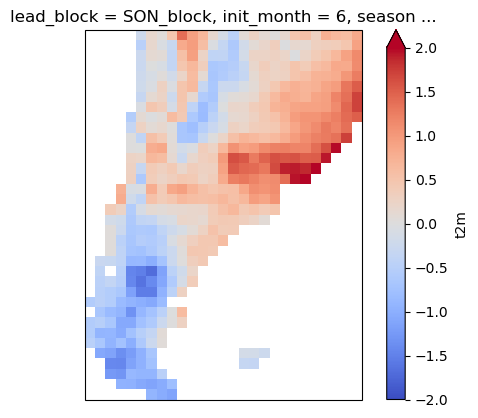

In [6]:
ax=plt.axes(projection=ccrs.PlateCarree())
target_SON_xr.isel(sample=10)['t2m'].plot(ax=ax, transform=ccrs.PlateCarree(), cmap='coolwarm', vmin=-2, vmax=2)

Start regressions

In [7]:
import sys
sys.path.insert(0, "../whole_period_effects")  # add Folder_2 path to search list

from Functions import plot_map, subplots_map

In [8]:
def modify_driver_list(driver_list, total_eff=False):

    controls_dict = {}

    for driver in driver_list:

        if not total_eff:
            controls = [d for d in driver_list if d != driver]

            # A-SAM has to be removed for symmetric response quantifications
            if 'A_SAM' in driver_list and driver in ['SPV', 'VB', 'S_SAM']:
                if 'A_SAM' in controls:
                    controls.remove('A_SAM')

            # Vortex and S-SAM need to be removed for asymmetric response
            elif ('SPV' in driver_list or 'VB' in driver_list) and driver == 'A_SAM':
                controls = [
                    c for c in controls
                    if c not in ['SPV', 'VB', 'S_SAM']
                ]

        else:
            if driver in ['IOD', 'IOBW']:
                controls = ['ENSO']
            elif driver == 'SPV':
                controls = ['ENSO', 'IOD']
            elif driver == 'VB':
                controls = ['ENSO', 'IOBW']
            else:
                controls = None

        controls_dict[driver] = controls

    return controls_dict

In [ ]:
# def bootstrap_regression_cell(
#     y,
#     drivers,
#     driver_vars,
#     n_boot=50,
#     sample_size=10000,
#     add_intercept=True,
#     seed=42,
#     total_eff=False,
# ):
    
#     n_samples = y.shape[0]

#     # --------------------------------------------------
#     # Convert the driver array into a dictionary
#     # --------------------------------------------------

#     driver_data = {
#         var: drivers[j, :]
#         for j, var in enumerate(driver_vars)
#     }

#     # --------------------------------------------------
#     # Determine controls
#     # --------------------------------------------------

#     controls_dict = modify_driver_list(
#         driver_vars,
#         total_eff=total_eff
#     )

#     # --------------------------------------------------
#     # Bootstrap indices
#     # --------------------------------------------------

#     rng = np.random.default_rng(seed)

#     bootstrap_indices = [
#         rng.choice(
#             n_samples,
#             size=sample_size,
#             replace=True
#         )
#         for _ in range(n_boot)
#     ]

#     n_drivers = len(driver_vars)

#     # --------------------------------------------------
#     # Output
#     # --------------------------------------------------

#     r2_out = np.full(
#         (n_boot, n_drivers),
#         np.nan
#     )

#     coef_out = np.full(
#         (n_boot, n_drivers),
#         np.nan
#     )

#     # --------------------------------------------------
#     # Regression for each driver
#     # --------------------------------------------------

#     for d, driver in enumerate(driver_vars):

#         controls = controls_dict[driver]

#         if controls is None:
#             regression_vars = [driver]
#         else:
#             regression_vars = [driver] + controls

#         # X for this grid cell
#         X_full = pd.DataFrame({
#             var: driver_data[var]
#             for var in regression_vars
#         })

#         # --------------------------------------------------
#         # Bootstrap
#         # --------------------------------------------------

#         for i, idx in enumerate(bootstrap_indices):

#             y_boot = y[idx]
#             X_boot = X_full.iloc[idx]

#             df = X_boot.copy()
#             df["target"] = y_boot

#             # Remove NaNs
#             df = df.dropna()

#             n_valid = len(df)

#             n_predictors = len(regression_vars)
#             n_parameters = (
#                 n_predictors
#                 + int(add_intercept)
#             )

#             if n_valid <= n_parameters:
#                 continue

#             X_clean = df[regression_vars]
#             y_clean = df["target"]

#             if add_intercept:
#                 X_clean = sm.add_constant(X_clean)

#             model = sm.OLS(
#                 y_clean,
#                 X_clean
#             ).fit()

#             r2_out[i, d] = model.rsquared
#             coef_out[i, d] = model.params[driver]

#     return r2_out, coef_out

In [10]:
def bootstrap_regression_cell(
    y,
    drivers,
    driver_vars,
    n_boot=50,
    sample_size=10000,
    add_intercept=True,
    seed=42,
    total_eff=False,
):
    """
    Fast bootstrap regression for one spatial grid cell.

    Parameters
    ----------
    y : np.ndarray
        Target variable, shape (sample,)

    drivers : np.ndarray
        Driver variables, shape (driver, sample)

    driver_vars : list
        Names of the driver variables.

    n_boot : int
        Number of bootstrap samples.

    sample_size : int
        Number of samples in each bootstrap replicate.

    add_intercept : bool
        Whether to include an intercept.

    seed : int
        Random seed.

    total_eff : bool
        Passed to modify_driver_list().

    Returns
    -------
    r2_out : np.ndarray
        Shape (n_boot, n_drivers)

    coef_out : np.ndarray
        Shape (n_boot, n_drivers)
    """

    # ============================================================
    # Basic dimensions
    # ============================================================

    n_samples = y.shape[0]
    n_drivers = len(driver_vars)

    # ============================================================
    # Driver dictionary
    # ============================================================

    driver_data = {
        var: drivers[j, :]
        for j, var in enumerate(driver_vars)
    }

    # ============================================================
    # Determine controls
    # ============================================================

    controls_dict = modify_driver_list(
        driver_vars,
        total_eff=total_eff
    )

    # ============================================================
    # Output arrays
    # ============================================================

    r2_out = np.full(
        (n_boot, n_drivers),
        np.nan,
        dtype=float
    )

    coef_out = np.full(
        (n_boot, n_drivers),
        np.nan,
        dtype=float
    )

    # ============================================================
    # Random generator
    # ============================================================

    rng = np.random.default_rng(seed)

    # ============================================================
    # Loop over drivers
    # ============================================================

    for d, driver in enumerate(driver_vars):

        # --------------------------------------------------------
        # Determine regression variables
        # --------------------------------------------------------

        controls = controls_dict[driver]

        if controls is None:
            regression_vars = [driver]
        else:
            regression_vars = [driver] + controls

        # --------------------------------------------------------
        # Build X matrix
        #
        # Shape:
        #     sample × predictor
        # --------------------------------------------------------

        X_full = np.column_stack([
            driver_data[var]
            for var in regression_vars
        ])

        y_full = y

        # --------------------------------------------------------
        # Remove invalid observations ONCE
        #
        # This replaces the pandas DataFrame + dropna()
        # that was previously executed for every bootstrap.
        # --------------------------------------------------------

        valid = np.isfinite(y_full)

        valid &= np.all(
            np.isfinite(X_full),
            axis=1
        )

        X_valid = X_full[valid]
        y_valid = y_full[valid]

        n_valid_total = y_valid.shape[0]

        # --------------------------------------------------------
        # Check whether there are enough observations
        # --------------------------------------------------------

        n_predictors = X_valid.shape[1]

        n_parameters = (
            n_predictors
            + int(add_intercept)
        )

        if n_valid_total <= n_parameters:
            continue

        # --------------------------------------------------------
        # Bootstrap indices
        #
        # Generate ALL bootstrap indices at once.
        #
        # Shape:
        #     n_boot × sample_size
        # --------------------------------------------------------

        bootstrap_indices = rng.integers(
            0,
            n_valid_total,
            size=(n_boot, sample_size)
        )

        # --------------------------------------------------------
        # Construct bootstrap samples
        #
        # X_boot:
        #     bootstrap × sample × predictor
        #
        # y_boot:
        #     bootstrap × sample
        # --------------------------------------------------------

        X_boot = X_valid[
            bootstrap_indices
        ]

        y_boot = y_valid[
            bootstrap_indices
        ]

        # --------------------------------------------------------
        # Add intercept
        # --------------------------------------------------------

        if add_intercept:

            intercept = np.ones(
                (
                    n_boot,
                    sample_size,
                    1
                ),
                dtype=X_boot.dtype
            )

            X_boot = np.concatenate(
                [
                    intercept,
                    X_boot
                ],
                axis=2
            )

        # --------------------------------------------------------
        # Solve all bootstrap regressions simultaneously
        #
        # X'X:
        #
        #     bootstrap × parameter × parameter
        #
        # X'y:
        #
        #     bootstrap × parameter
        # --------------------------------------------------------

        XtX = np.einsum(
            "bsp,bsq->bpq",
            X_boot,
            X_boot,
            optimize=True
        )

        Xty = np.einsum(
            "bsp,bs->bp",
            X_boot,
            y_boot,
            optimize=True
        )

        # --------------------------------------------------------
        # Solve:
        #
        #     beta = (X'X)^-1 X'y
        #
        # np.linalg.solve works on the bootstrap dimension
        # simultaneously.
        # --------------------------------------------------------

        try:

            beta = np.linalg.solve(
                XtX,
                Xty
            )

        except np.linalg.LinAlgError:

            # Fall back to individual bootstrap regressions
            # if some matrices are singular.
            #
            # This is uncommon, but can happen with strongly
            # collinear controls or bootstrap samples.

            for i in range(n_boot):

                try:

                    beta_i = np.linalg.lstsq(
                        X_boot[i],
                        y_boot[i],
                        rcond=None
                    )[0]

                    beta[i] = beta_i

                except np.linalg.LinAlgError:

                    continue

        # --------------------------------------------------------
        # Predicted values
        #
        # Shape:
        #     bootstrap × sample
        # --------------------------------------------------------

        y_hat = np.einsum(
            "bsp,bp->bs",
            X_boot,
            beta,
            optimize=True
        )

        # --------------------------------------------------------
        # Residual sum of squares
        # --------------------------------------------------------

        residual = y_boot - y_hat

        ss_res = np.sum(
            residual ** 2,
            axis=1
        )

        # --------------------------------------------------------
        # Total sum of squares
        # --------------------------------------------------------

        y_mean = np.mean(
            y_boot,
            axis=1
        )

        ss_tot = np.sum(
            (y_boot - y_mean[:, None]) ** 2,
            axis=1
        )

        # --------------------------------------------------------
        # R²
        # --------------------------------------------------------

        valid_r2 = ss_tot > 0

        r2 = np.full(
            n_boot,
            np.nan,
            dtype=float
        )

        r2[valid_r2] = (
            1.0
            - ss_res[valid_r2]
            / ss_tot[valid_r2]
        )

        # --------------------------------------------------------
        # Store R²
        # --------------------------------------------------------

        r2_out[:, d] = r2

        # --------------------------------------------------------
        # Store coefficient of focal driver
        #
        # beta[:, 0] is the intercept if add_intercept=True.
        #
        # The focal driver is ALWAYS the first element of
        # regression_vars.
        # --------------------------------------------------------

        if add_intercept:
            coef_index = 1
        else:
            coef_index = 0

        coef_out[:, d] = beta[:, coef_index]

    return r2_out, coef_out

In [11]:
def bootstrap_map(target_xr,drivers_combi_xr, driver_vars, target_var, n_boot=5, sample_size=200, total_eff=False):
    drivers_array = xr.concat(
    [drivers_combi_xr[var] for var in driver_vars],
    dim="driver"
    ).assign_coords(
        driver=driver_vars
    )

    r2, coef = xr.apply_ufunc(
    bootstrap_regression_cell,

    target_xr[target_var],
    drivers_array,

    input_core_dims=[
        ["sample"],
        ["driver", "sample"],
    ],

    output_core_dims=[
        ["bootstrap", "driver"],
        ["bootstrap", "driver"],
    ],

    vectorize=True,

    output_dtypes=[
        float,
        float,
    ],

    kwargs={
        "driver_vars": driver_vars,
        "n_boot": n_boot,
        "sample_size": sample_size,
        "add_intercept": True,
        "seed": 42,
        "total_eff": total_eff,
    },

    dask="parallelized",

    dask_gufunc_kwargs={
        "output_sizes": {
            "bootstrap": n_boot,
            "driver": len(driver_vars),
        }
    },
    )

    return r2, coef

# Perform regressions and plot maps

Precipitation Spring

In [ ]:
driver_vars = ["ENSO", "IOD", 'SPV', 'S_SAM', 'A_SAM']
driver_vars_tot=['ENSO', 'IOD', 'SPV']

r2_SON_precip_direct, coef_SON_precip_direct=bootstrap_map(target_SON_xr, drivers_SON_xr, 
                                                           driver_vars, target_var='tp', n_boot=100, 
                                                        sample_size=200, total_eff=False)

In [ ]:
r2_SON_precip_total, coef_SON_precip_total=bootstrap_map(target_SON_xr, drivers_SON_xr,
                                                           driver_vars_tot, target_var='tp', n_boot=100,
                                                        sample_size=200, total_eff=True)

Temperature Spring

In [ ]:
r2_SON_temp_direct, coef_SON_temp_direct=bootstrap_map(target_SON_xr, drivers_SON_xr, 
                                                       driver_vars, target_var='t2m', n_boot=100,
                                                         sample_size=200, total_eff=False)

In [ ]:
r2_SON_temp_total, coef_SON_temp_total=bootstrap_map(target_SON_xr, drivers_SON_xr,
                                                     driver_vars_tot, target_var='t2m', n_boot=100,
                                                        sample_size=200, total_eff=True)

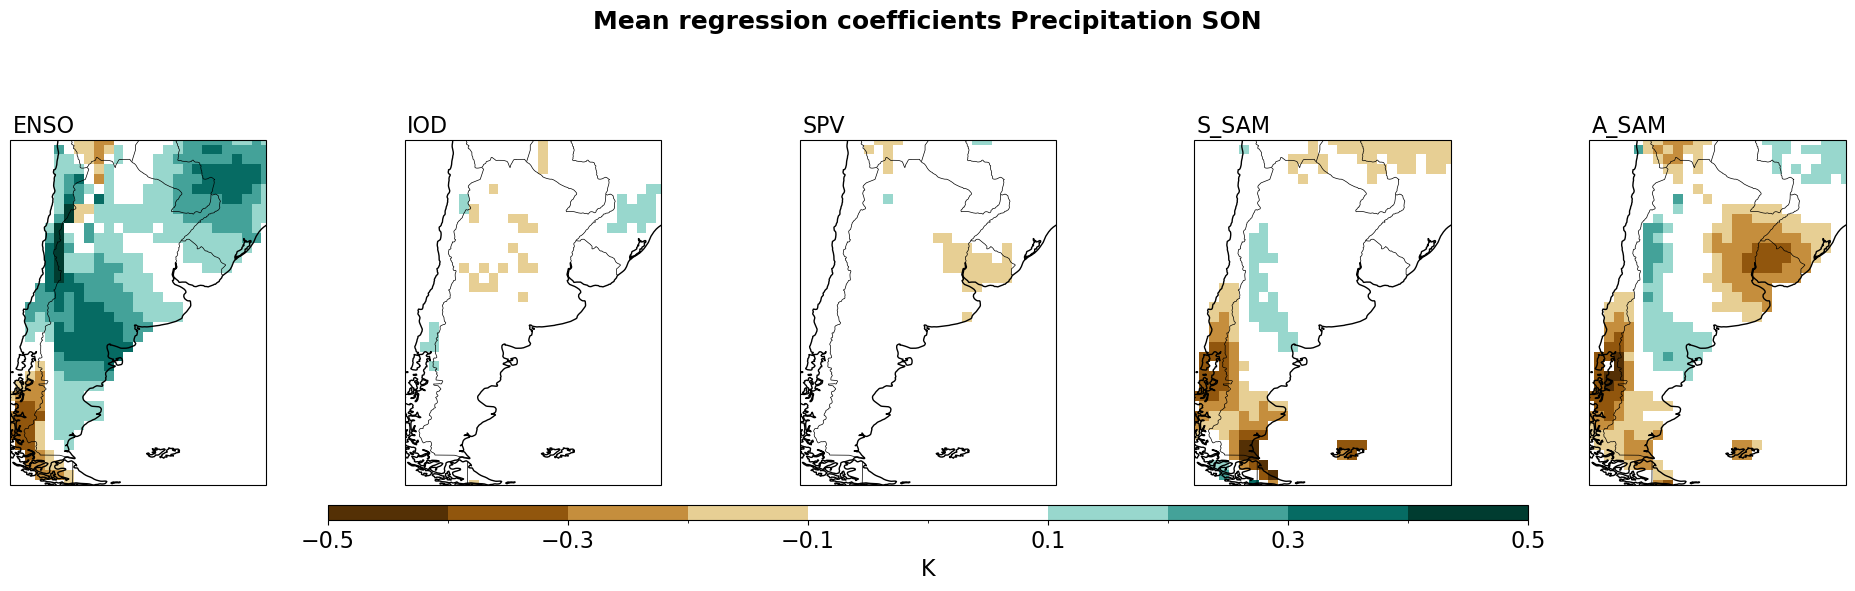

In [ ]:
coef_mean_SON_precip_direct = coef_SON_precip_direct.mean(dim="bootstrap", skipna=True).transpose('driver', 'latitude', 'longitude')

subplots_map(ds=coef_mean_SON_precip_direct, title_list=driver_vars, cmap=plt.cm.BrBG, unit='mm', steps=0.1, \
                 cbar_each=None, heading='Mean regression coefficients Precipitation SON',
                   stations=None)
coef_mean_SON_precip_total = coef_SON_precip_total.mean(dim="bootstrap", skipna=True).transpose('driver', 'latitude', 'longitude')

subplots_map(ds=coef_mean_SON_precip_total, title_list=driver_vars_tot, cmap=plt.cm.BrBG, unit='mm', steps=0.1, \
                 cbar_each=None, heading='Mean regression coefficients Precipitation SON',
                   stations=None)

coef_mean_SON_temp_direct = coef_SON_temp_direct.mean(dim="bootstrap", skipna=True).transpose('driver', 'latitude', 'longitude')

subplots_map(ds=coef_mean_SON_temp_direct, title_list=driver_vars, cmap=plt.cm.RdBu_r, unit='K', steps=0.1, \
                 cbar_each=None, heading='Mean regression coefficients Temperature SON',
                   stations=None)

coef_mean_SON_temp_total = coef_SON_temp_total.mean(dim="bootstrap", skipna=True).transpose('driver', 'latitude', 'longitude')

subplots_map(ds=coef_mean_SON_temp_total, title_list=driver_vars_tot, cmap=plt.cm.RdBu_r, unit='K', steps=0.1, \
                 cbar_each=None, heading='Mean regression coefficients Temperature SON',
                   stations=None)